In [16]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers_cupy import *

In [22]:
#minor style things to make the figures look nice
#plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 15
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [34]:
N_order = 1              # 3 for 3P, 2 for 2P
lambd = 5.32e-4             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.2            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                   # Magnification rate from input to objective
w_0 = 3.5                 # mm
alpha = np.arcsin(num_apt / n)


#256 x 256
grid_ffp = 256
#.104 micron pixel size
L_ffp = 0.104e-3 * grid_ffp
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)
x_bfp, y_bfp = np.meshgrid(x_bfp, y_bfp)

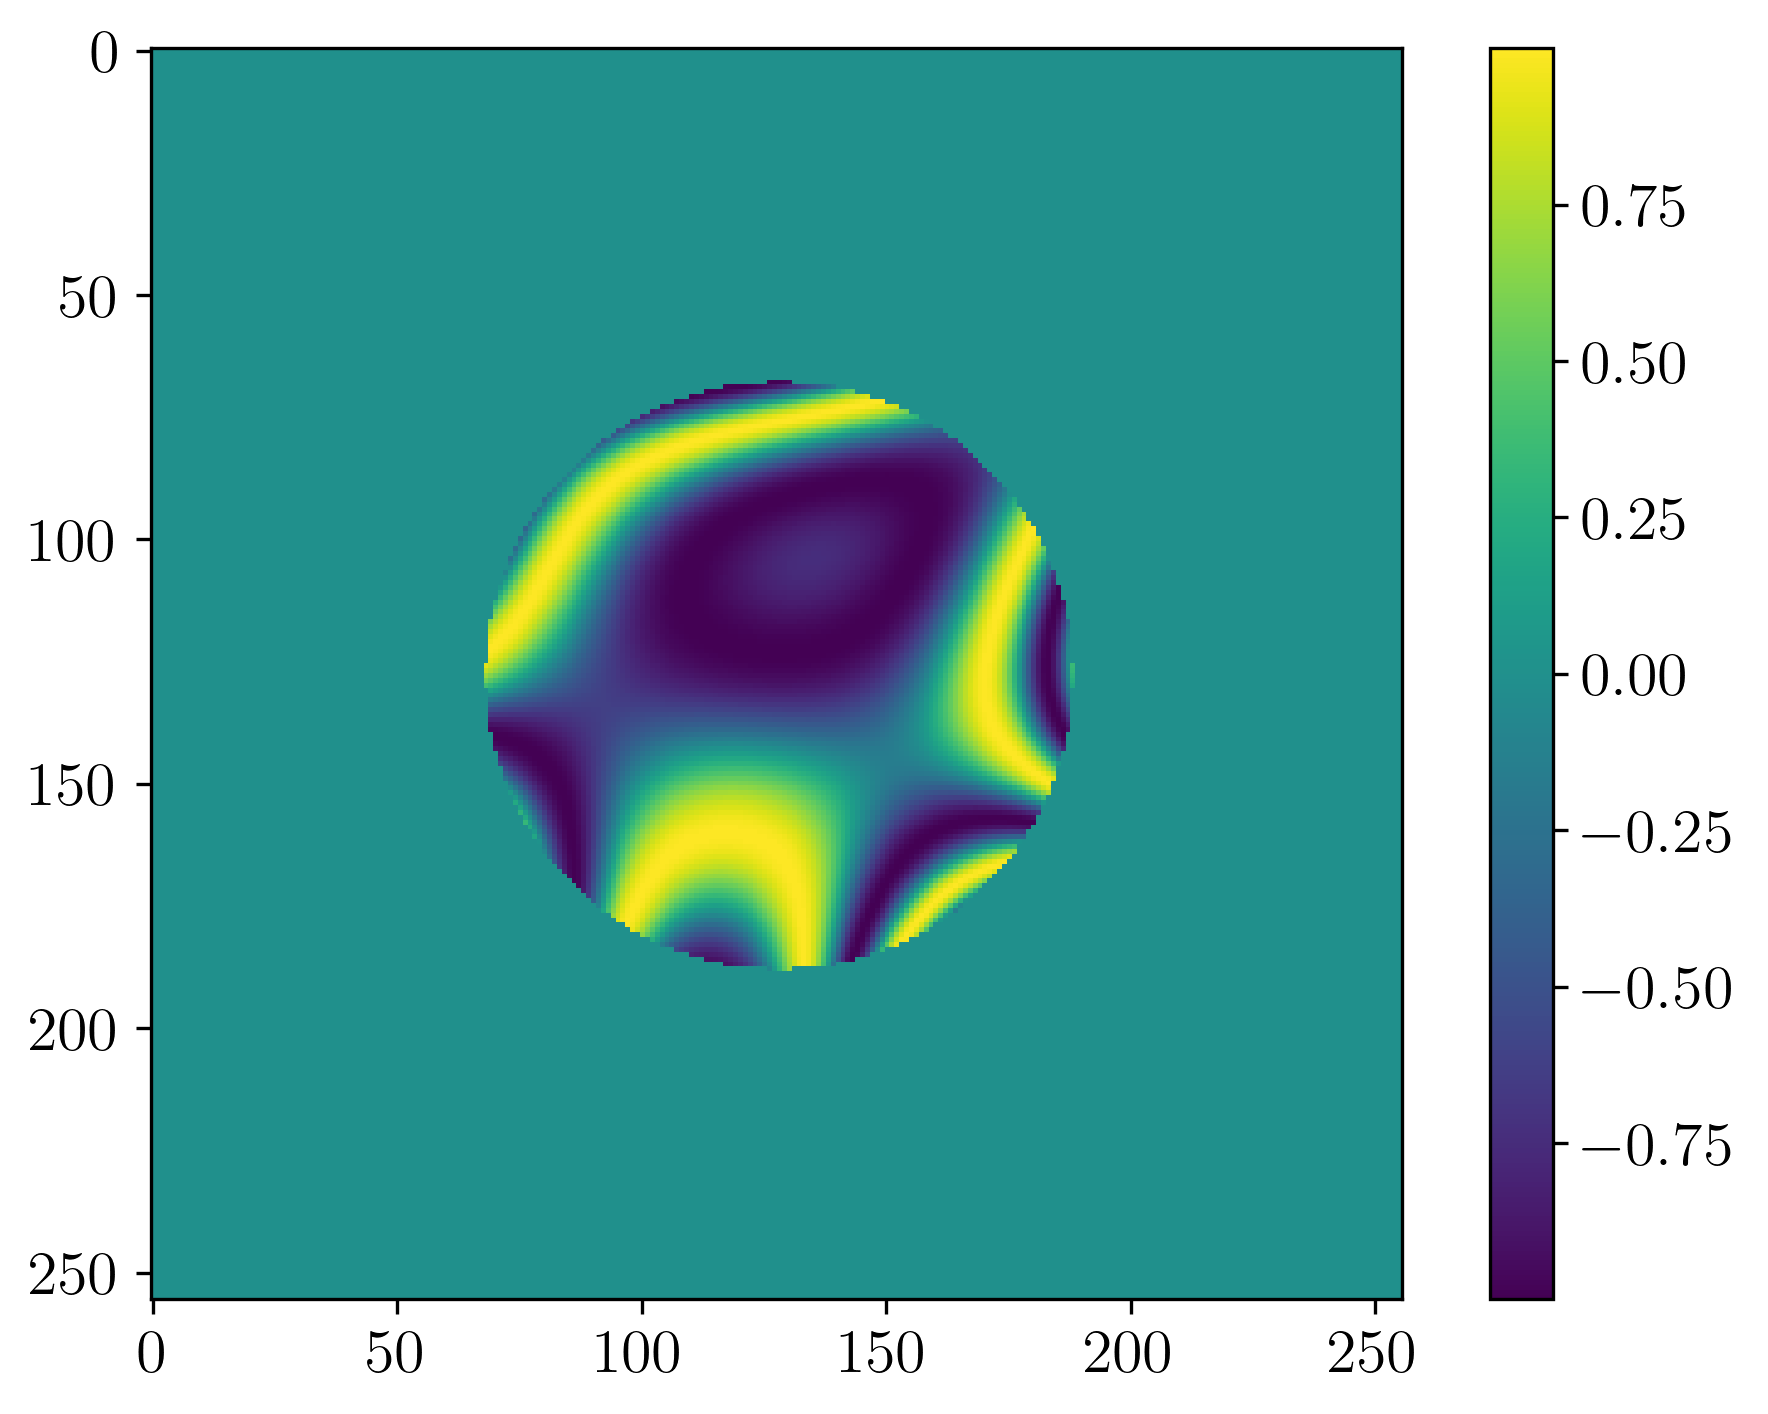

In [81]:
rng = np.random.default_rng(15)
true_aberration = generate_johnson_aberration(150/532, alpha, rng)
plt.imshow(np.imag(microscope.compute_pupil_function(true_aberration, False)))
plt.colorbar()

In [74]:
f = np.load("images/usaf_resolution.npy")
f_cropped = np.zeros((256, 256))
for i in range(256):
    for j in range(256):
        f_cropped[i, j] = np.mean(f[2*i:2*i+1, 2*j:2*j+1])

f = ((f_cropped - np.min(f_cropped))/ (np.max(f_cropped) - np.min(f_cropped))) * 255

FIG S2(B)

In [82]:
def add_gaussian_noise_stack(img_stack, SNR, rng, percentile = 90):
    sigma_noise = np.percentile(img_stack[0], percentile) / SNR
    return img_stack + rng.normal(0, sigma_noise, np.shape(img_stack))


In [83]:
SNR_vals = [5, 10, 20]
gamma_vals = [10**(-1 * x ) for x in range(1, 31)]
num_samples = 1

modes_corrected = get_johnson_modes()

rng = np.random.default_rng(20)

bias_modes = [[-2,2]]
#.5 microns -> 500 nm -> 500/532 waves
bias_strength = 500/532 
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]

c_converged = np.zeros((num_samples, len(SNR_vals), len(gamma_vals), len(modes_corrected)))
c_true = np.zeros((num_samples, len(SNR_vals), len(gamma_vals), len(modes_corrected)))
for i in range(num_samples):

    true_aberration = generate_johnson_aberration(150/532, alpha, rng)
    img_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])

    for j, SNR in enumerate(SNR_vals):
        d_stack = add_gaussian_noise_stack(img_stack, SNR, rng)
        
        for k, gamma in enumerate(gamma_vals):

            params = {
                "gamma": gamma,
                "J_tol": 0.001,
                "max_step": np.inf
            }


            c_guess, F_guess  = loop_optimize(n_loops = 100,
                                            microscope = microscope,
                                            d_stack = d_stack,
                                            a_stack = a_stack,
                                            modes_corrected = modes_corrected,
                                            params = params,
                                            debug = False,
                                            log = False)
            
            c_converged[i, j, k] = c_guess
            c_true[i, j, k] = true_aberration.strengths

np.save("results/gamma_1p_true.npy", c_true)
np.save("results/gamma_1p_converged.npy", c_converged)

 35%|███▌      | 35/100 [00:04<00:09,  7.04it/s]


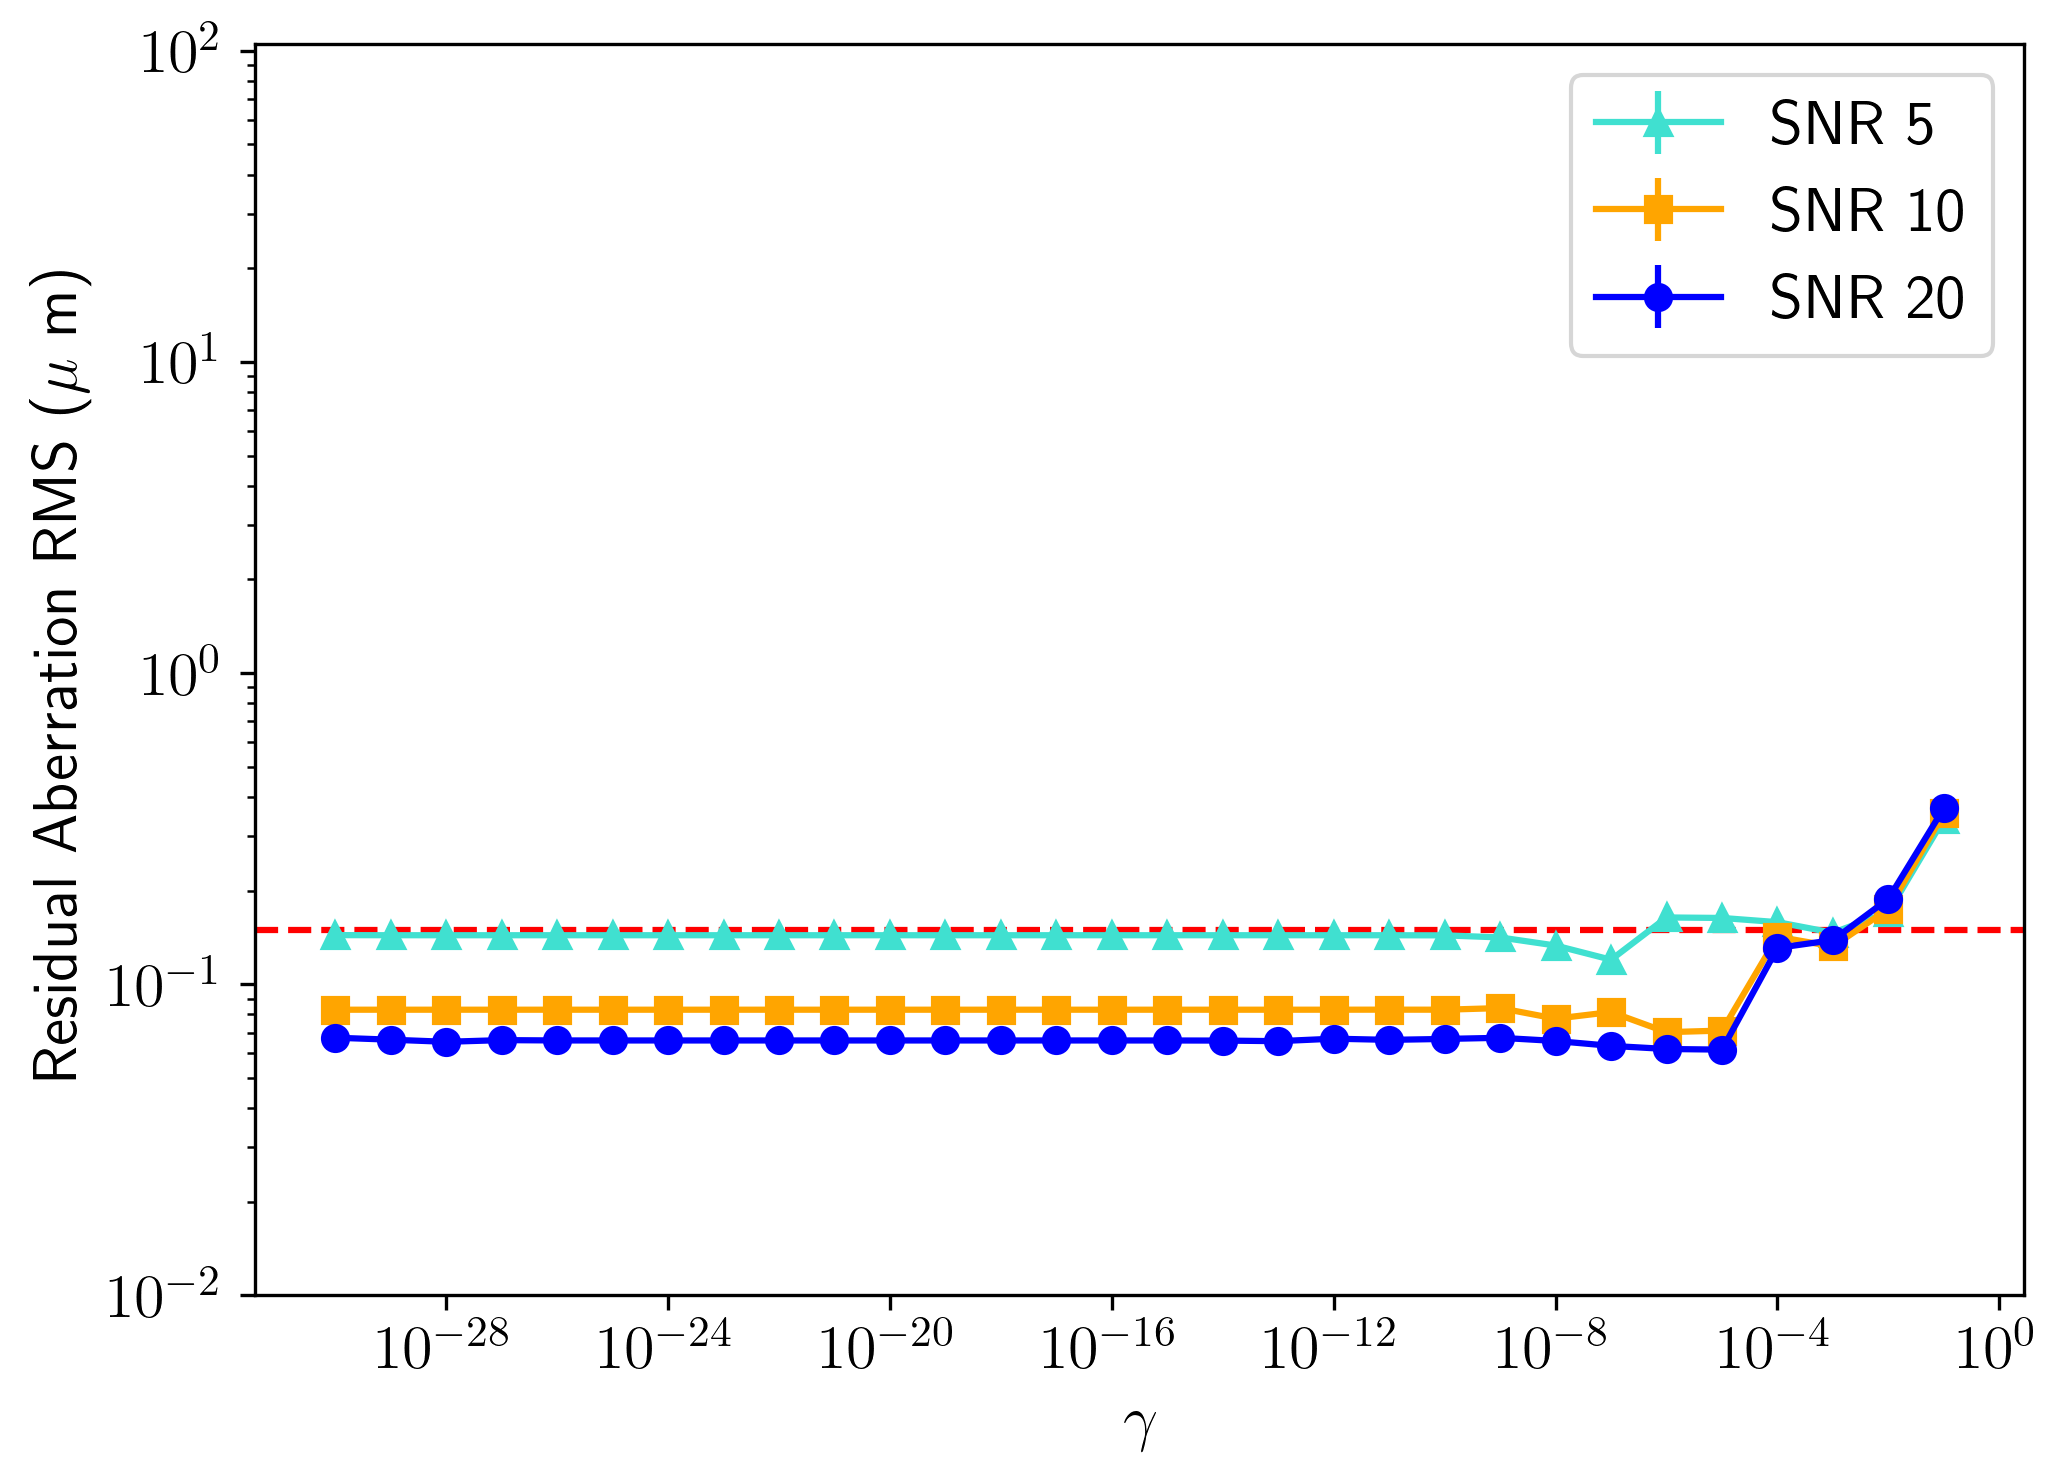

In [84]:
c_true = np.load("results/gamma_1p_true.npy")
c_converged = np.load("results/gamma_1p_converged.npy")

fig, ax = plt.subplots(dpi=300)

colors = ["turquoise", "orange", "blue"]
markers = ["^", "s", "o"]
for j, SNR in enumerate(SNR_vals):
    rms_list = np.zeros((len(gamma_vals), num_samples))

    for k, gamma in enumerate(gamma_vals):
        rms = np.zeros(num_samples)

        for i in range(num_samples):
            this_c_true = c_true[i, j, k]
            this_c_converged = c_converged[i, j, k]

            a_true = Aberration(get_johnson_modes(), this_c_true)
            a_converged = Aberration(get_johnson_modes(), this_c_converged)

            rms[i] = zernike_RMS_difference(a_true, a_converged, alpha) 

        rms_list[k] = rms * (532/1000)

    ax.errorbar(
        gamma_vals,
        np.mean(rms_list, axis=1),
        np.std(rms_list, axis=1),
        label=f"SNR {SNR}",
        marker = markers[j],
        c = colors[j]
    )

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$\gamma$")
ax.set_ylabel("Residual Aberration RMS ($\mu$ m)")
ax.set_ylim(0.01, 105)
ax.axhline(zernike_RMS(a_true, alpha) * (532/1000), color = "red", ls = "dashed")

FIG S2(C)

In [ ]:
SNR_vals = [3.0, 5.0, 10.0, 20.0]
#microns to waves 
rms_vals_microns = np.array([0.02,0.24])# 0.04, 0.06, 0.08, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.24])
rms_vals = rms_vals_microns * (1000/532)
num_samples = 1

modes_corrected = get_johnson_modes()
rng = np.random.default_rng(15)

GAMMA = 1e-6

bias_modes = [[2,2],
               [-2,2],
               [2,2],
               [-2,2]]


#convert from microns to waves -> 1000 nm per micron, 1 wv per 523 nm
bias_strengths = np.array([0.5, 0.5, -0.5, -0.5], dtype = np.float64) * (1000/532)
a_stack = [EmptyAberration()] + [Aberration([bias_modes[i]], [bias_strengths[i]]) for i in range(len(bias_modes))]

c_converged = np.zeros((num_samples, len(SNR_vals), len(rms_vals), len(modes_corrected)))
c_true = np.zeros((num_samples, len(SNR_vals), len(rms_vals), len(modes_corrected)))
for i in range(num_samples):

    raw_aberration = generate_johnson_aberration(1, alpha, rng)
    
    for j, SNR in enumerate(SNR_vals):
        for k, rms in enumerate(rms_vals):

            #rescale the strength of the true aberration
            true_aberration = rescale_aberration(raw_aberration, rms, alpha)
            img_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])
            d_stack = [add_gaussian_noise(img, SNR, rng) for img in img_stack]
            
            params = {
                "gamma": GAMMA,
                "J_tol": 0.001,
                "max_step": np.inf
            }

            c_guess, F_guess  = loop_optimize(n_loops = 100,
                                            microscope = microscope,
                                            d_stack = d_stack,
                                            a_stack = a_stack,
                                            modes_corrected = modes_corrected,
                                            params = params,
                                            debug = False,
                                            log = False)
            
            c_converged[i, j, k] = c_guess
            c_true[i, j, k] = true_aberration.strengths

np.save("results/snr_1p_true.npy", c_true)
np.save("results/snr_1p_converged.npy", c_converged)



 21%|██        | 21/100 [00:20<01:24,  1.07s/it]

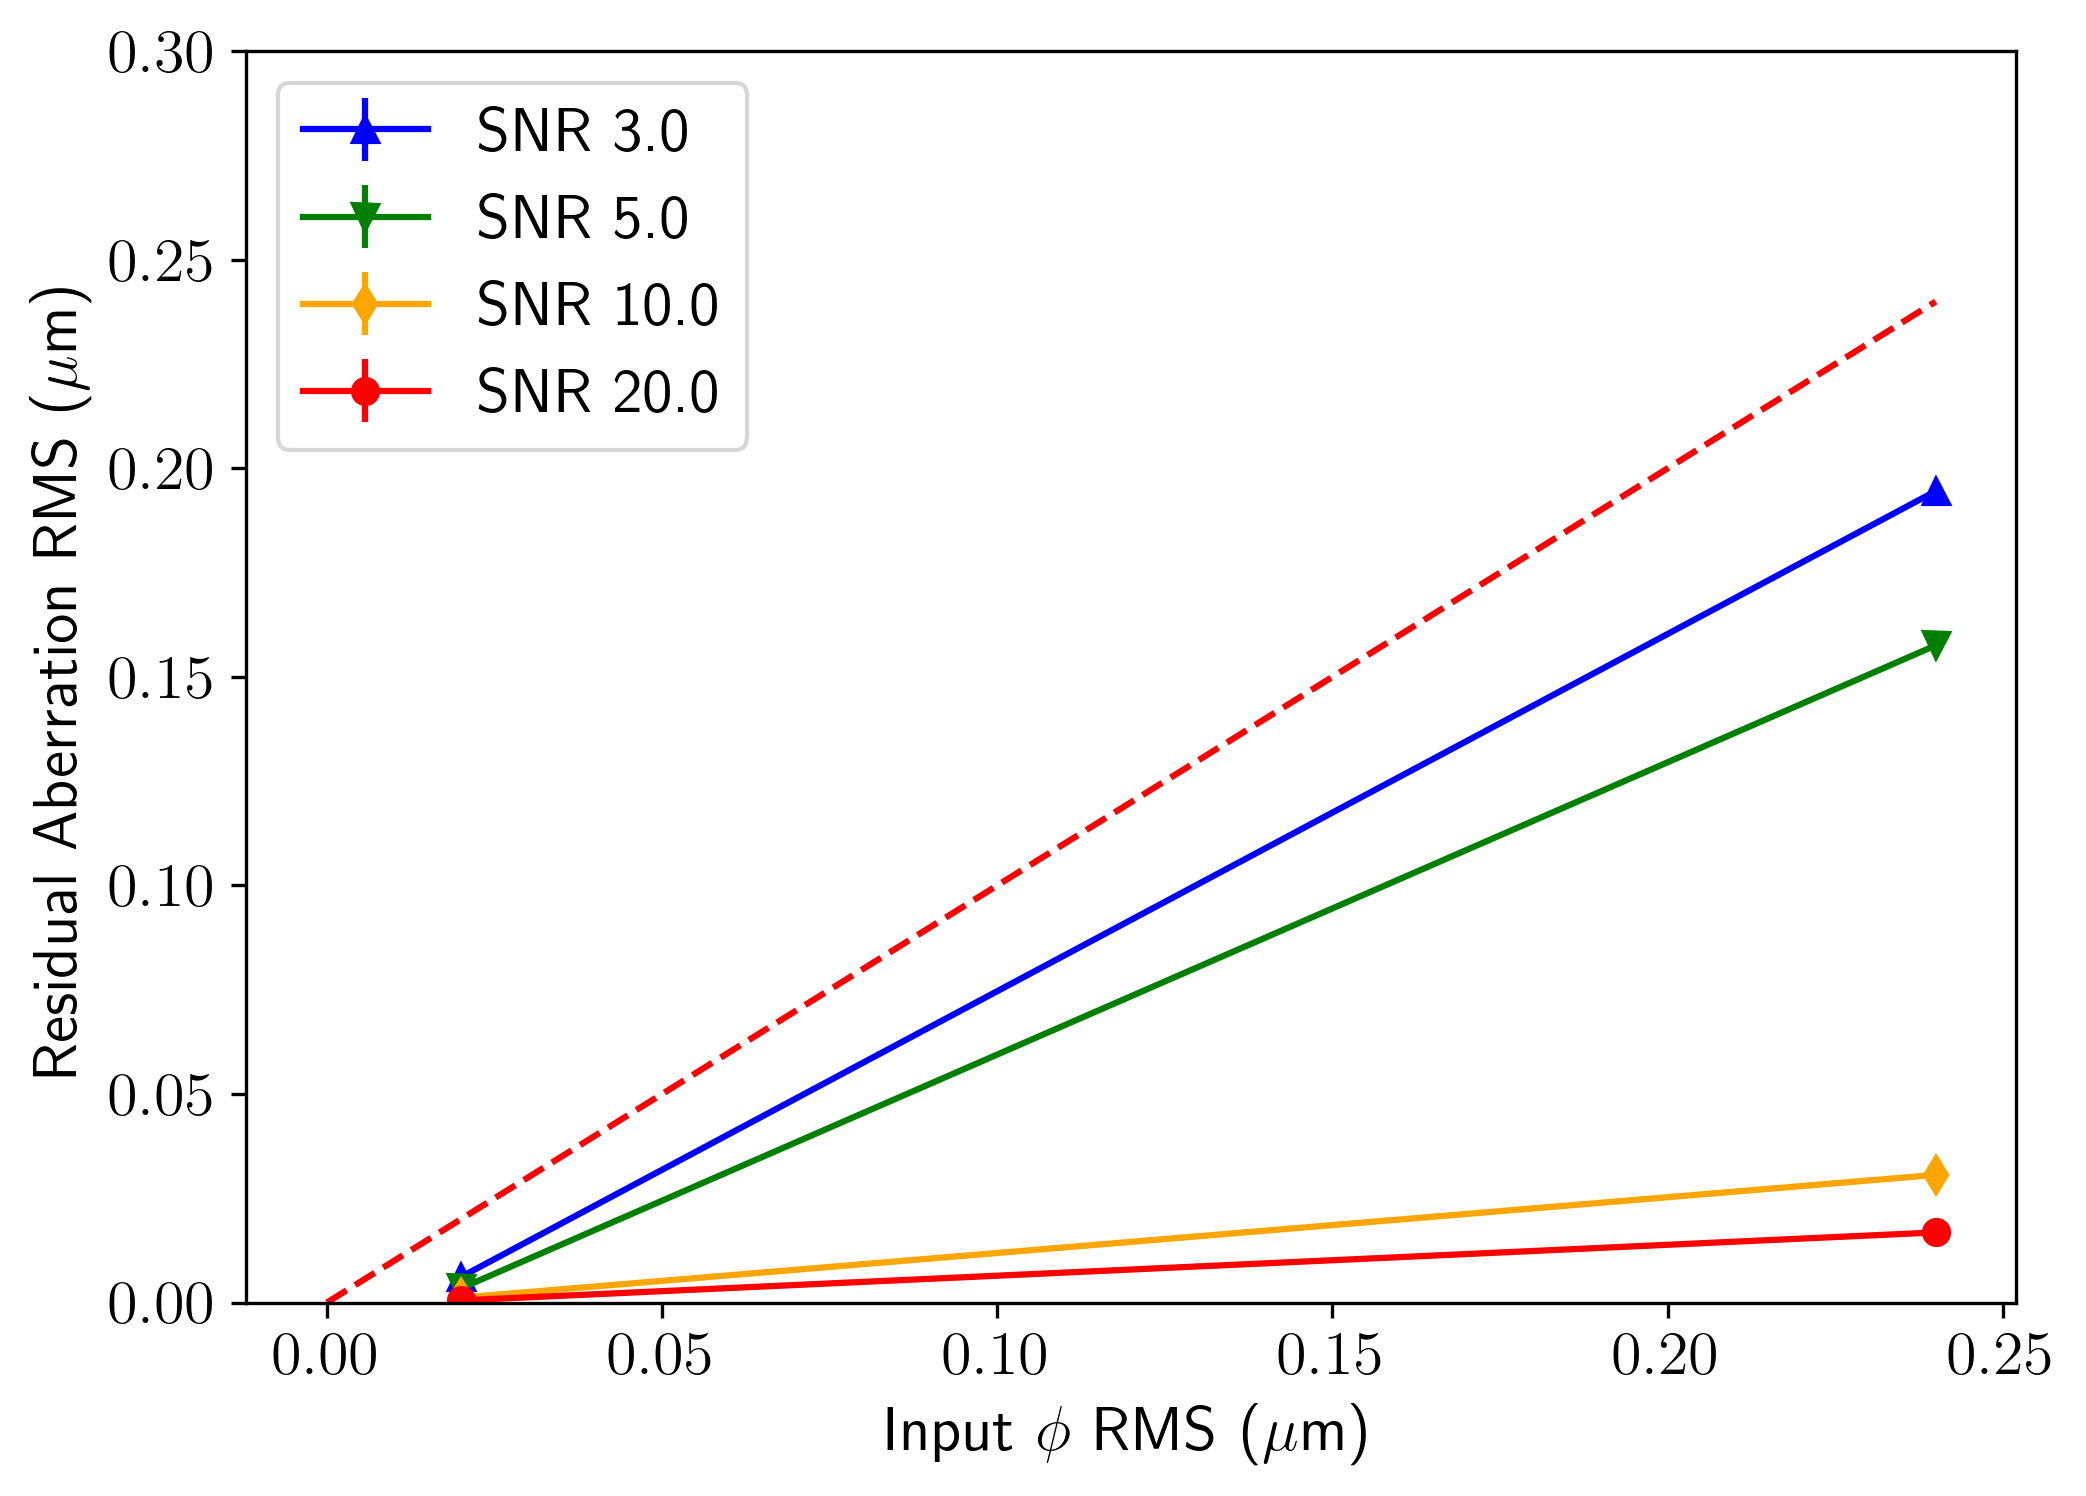

In [68]:
c_true = np.load("results/snr_1p_true.npy")
c_converged = np.load("results/snr_1p_converged.npy")
modes = get_johnson_modes()

fig, ax = plt.subplots(dpi=300)

colors = ["blue", "green", "orange", "red"]
markers = ["^", "v", "d", "o"]
for j, SNR in enumerate(SNR_vals):
    rms_list = np.zeros((len(rms_vals_microns), num_samples))

    for k, img_rms in enumerate(rms_vals_microns):
        rms = np.zeros(num_samples)

        for i in range(num_samples):
            this_c_true = c_true[i, j, k]
            this_c_converged = c_converged[i, j, k]

            a_true = Aberration(modes, this_c_true)
            a_converged = Aberration(modes, this_c_converged)

            rms[i] = zernike_RMS_difference(a_true, a_converged, alpha) 

        rms_list[k] = rms * (532/1000)
        #* 532 nm / wv * 1 mum /1000 nm

    ax.errorbar(
        rms_vals_microns,
        np.mean(rms_list, axis=1),
        np.std(rms_list, axis=1),
        label=f"SNR {SNR}",
        marker = markers[j],
        c = colors[j]
    )

ax.legend()
#ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("Input $\phi$ RMS ($\mu$m)")
ax.set_ylabel("Residual Aberration RMS ($\mu$m)")
ax.set_ylim(0, 0.3)
x = np.arange(0, 0.25, 0.01)
ax.plot(x, x, ls = "dashed", color = "red")
plt.savefig("figures/snr_input_rms")

FIG 2(D)

In [19]:
GAMMA = 1e-6
SNR = 10
num_samples = 10
modes_corrected = get_johnson_modes()
rng = np.random.default_rng(15)


true_aberration = generate_johnson_aberration(150/532, alpha, rng)

#defocus
#astigmatism
#spherical
#mix of defocus and astigmatism
bias_mode_sets = [[[0,2]],
              [[2,2]],
              [[0,4]],
              [[0,2],[2,2]]]

bias_rms_microns = np.concatenate([[0.01, 0.05, 0.1, 0.15], np.arange(0.2, 2.1, 0.1)])
#convert from microns to waves -> 1000 nm per micron, 1 wv per 523 nm
bias_rms_vals = bias_rms_microns * (1000/532)



c_converged = np.zeros((num_samples, len(bias_mode_sets), len(bias_rms_vals), len(modes_corrected)))
c_true = np.zeros((num_samples, len(bias_mode_sets), len(bias_rms_vals), len(modes_corrected)))
for i in range(num_samples):
    
    for j, bias_mode_set in enumerate(bias_mode_sets):
        for k, bias_rms in enumerate(bias_rms_vals):
            raw_bias_aberration = Aberration(bias_mode_set, [bias_rms] * len(bias_mode_set))
            #scaled_bias_aberration = rescale_aberration(raw_bias_aberration, bias_rms, alpha)
            a_stack = [EmptyAberration(), raw_bias_aberration]
            
            img_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])
            d_stack = [add_gaussian_noise(img, SNR, rng) for img in img_stack]
            
            params = {
                "gamma": GAMMA,
                "J_tol": 0.001,
                "max_step": np.inf
            }

            c_guess, F_guess  = loop_optimize(n_loops = 100,
                                            microscope = microscope,
                                            d_stack = d_stack,
                                            a_stack = a_stack,
                                            modes_corrected = modes_corrected,
                                            params = params,
                                            debug = False,
                                            log = False)
            
            c_converged[i, j, k] = c_guess
            c_true[i, j, k] = true_aberration.strengths

np.save("results/bias_type_1p_true.npy", c_true)
np.save("results/bias_type_1p_converged.npy", c_converged)

  3%|▎         | 3/100 [00:00<00:20,  4.70it/s]


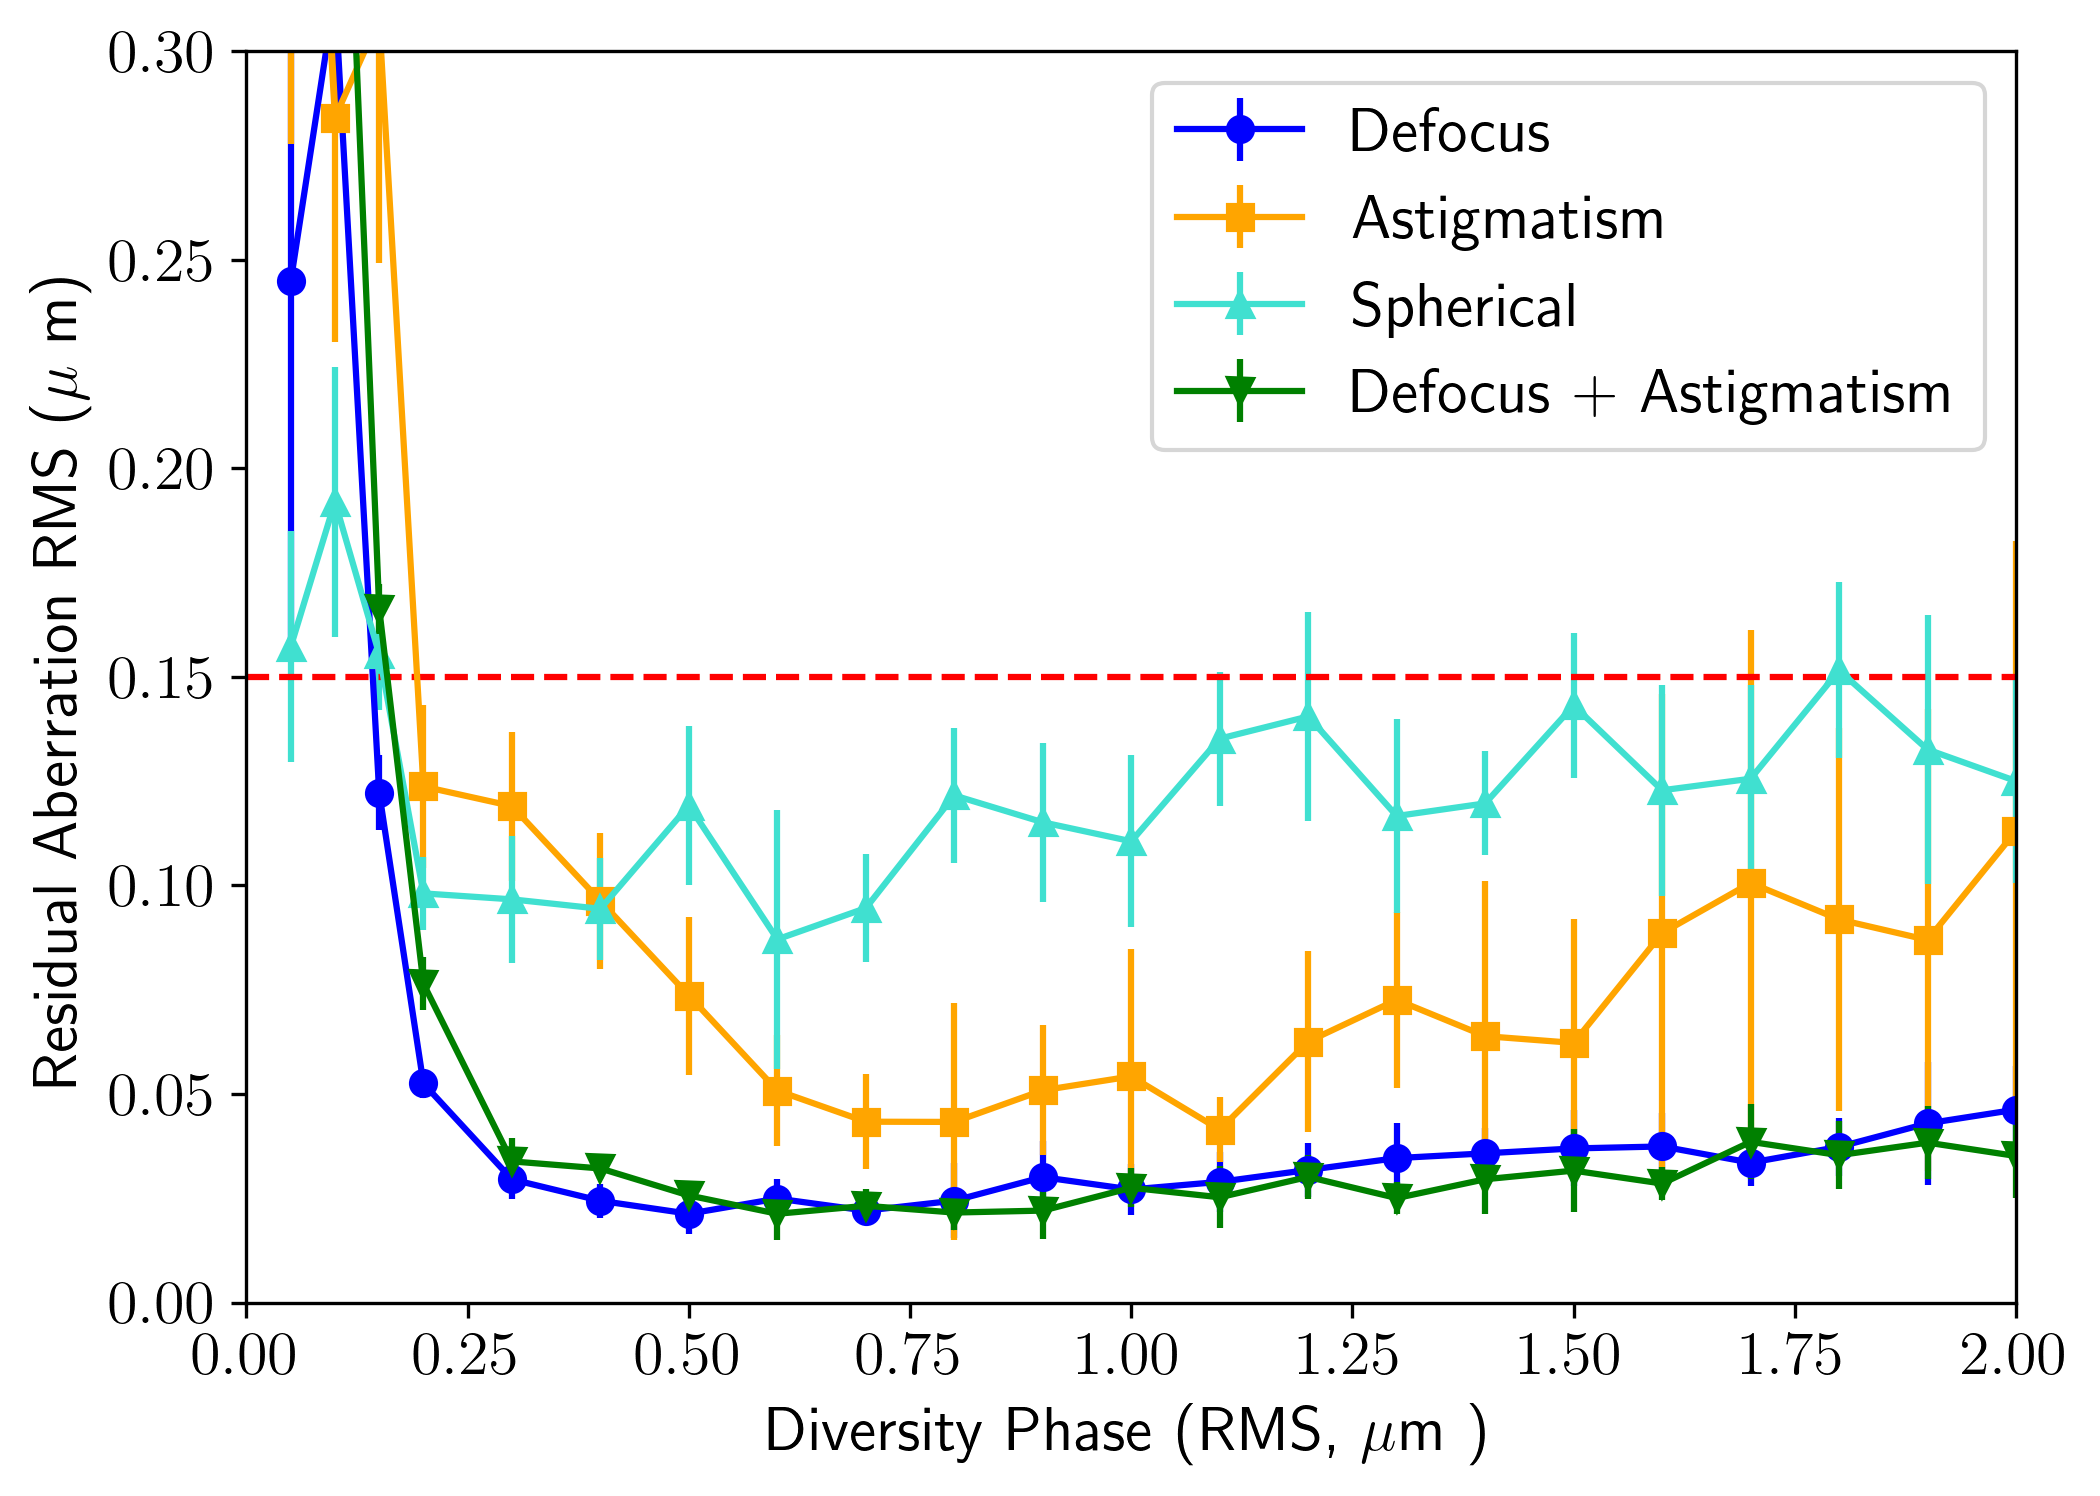

In [44]:
num_samples = 10

c_true = np.load("results/bias_type_1p_true.npy")
c_converged = np.load("results/bias_type_1p_converged.npy")
modes = get_johnson_modes()

fig, ax = plt.subplots(dpi=300)

colors = ["blue", "orange", "turquoise", "green"]
markers = ["o", "s", "^", "v"]
mode_names = ["Defocus", "Astigmatism", "Spherical", "Defocus + Astigmatism"]
for j, mode_name in enumerate(mode_names):
    rms_list = np.zeros((len(bias_rms_vals), num_samples))

    for k, rms_bias in enumerate(bias_rms_microns):
        rms = np.zeros(num_samples)

        for i in range(num_samples):
            this_c_true = c_true[i, j, k]
            this_c_converged = c_converged[i, j, k]

            a_true = Aberration(modes, this_c_true)
            a_converged = Aberration(modes, this_c_converged)

            rms[i] = zernike_RMS_difference(a_true, a_converged, alpha) 

        rms_list[k] = rms * (532/1000)
        #* 523 nm / wv * 1 mum /1000 nm

    ax.errorbar(
        bias_rms_microns[1:],
        np.mean(rms_list, axis=1)[1:],
        np.std(rms_list, axis=1)[1:],
        label=f"{mode_name}",
        marker = markers[j],
        c = colors[j]
    )

ax.legend()
ax.set_xlabel("Diversity Phase (RMS, $\mu$m )")
ax.set_ylabel("Residual Aberration RMS ($\mu$ m)")
ax.set_ylim(0, 0.3)
ax.set_xlim(0, 2)
ax.axhline(zernike_RMS(a_true, alpha) * (532/1000), color = "red", ls = "dashed")
plt.savefig("figures/diversity_type.png")

In [42]:
GAMMA = 1e-6
SNR = 10
num_samples = 10
modes_corrected = get_johnson_modes()
rng = np.random.default_rng(30)

raw_aberration = generate_johnson_aberration(1, alpha, rng)

bias_mode_sets = [
        [[2,2]],
        [[2,2], [-2,2]],
        [[2,2], [-2,2], [2,2]],
        [[2,2], [-2,2], [2,2], [-2,2]],
        [[2,2], [-2,2], [2,2], [-2,2], [0,4]]
]

strength_micron_sets = [
        [0.5],
        [0.5, 0.5],
        [0.5, 0.5, -0.5],
        [0.5, 0.5, -0.5, -0.5],
        [0.5, 0.5, -0.5, -0.5, 0.5],
]
#convert from microns to waves -> 1000 nm per micron, 1 wv per 523 nm
strength_sets = [
    np.array(s, dtype=float) * (1000 / 532)
    for s in strength_micron_sets
]

rms_vals_microns = np.array([0.02, 0.04, 0.06, 0.08, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.24])
rms_vals = rms_vals_microns * (1000/532)

c_converged = np.zeros((num_samples, len(bias_mode_sets), len(rms_vals), len(modes_corrected)))
c_true = np.zeros((num_samples, len(bias_mode_sets), len(rms_vals), len(modes_corrected)))
for i in range(num_samples):
    
    for j, bias_mode_set in enumerate(bias_mode_sets):
            strength_set = strength_sets[j]

            bias_aberrations = [Aberration([bias_mode_set[i]], [strength_set[i]]) for i in range(len(bias_mode_set))]
            a_stack = [EmptyAberration()] + bias_aberrations

            for k, rms_val in enumerate(rms_vals):        
                true_aberration = rescale_aberration(raw_aberration, rms_val, alpha)    
                img_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])
                d_stack = [add_gaussian_noise(img, SNR, rng) for img in img_stack]
                
                params = {
                    "gamma": GAMMA,
                    "J_tol": 0.001,
                    "max_step": np.inf
                }

                c_guess, F_guess  = loop_optimize(n_loops = 100,
                                                microscope = microscope,
                                                d_stack = d_stack,
                                                a_stack = a_stack,
                                                modes_corrected = modes_corrected,
                                                params = params,
                                                debug = False,
                                                log = False)
                
                c_converged[i, j, k] = c_guess
                c_true[i, j, k] = true_aberration.strengths

np.save("results/bias_num_1p_true.npy", c_true)
np.save("results/bias_num_1p_converged.npy", c_converged)



  5%|▌         | 5/100 [00:12<03:59,  2.52s/it]


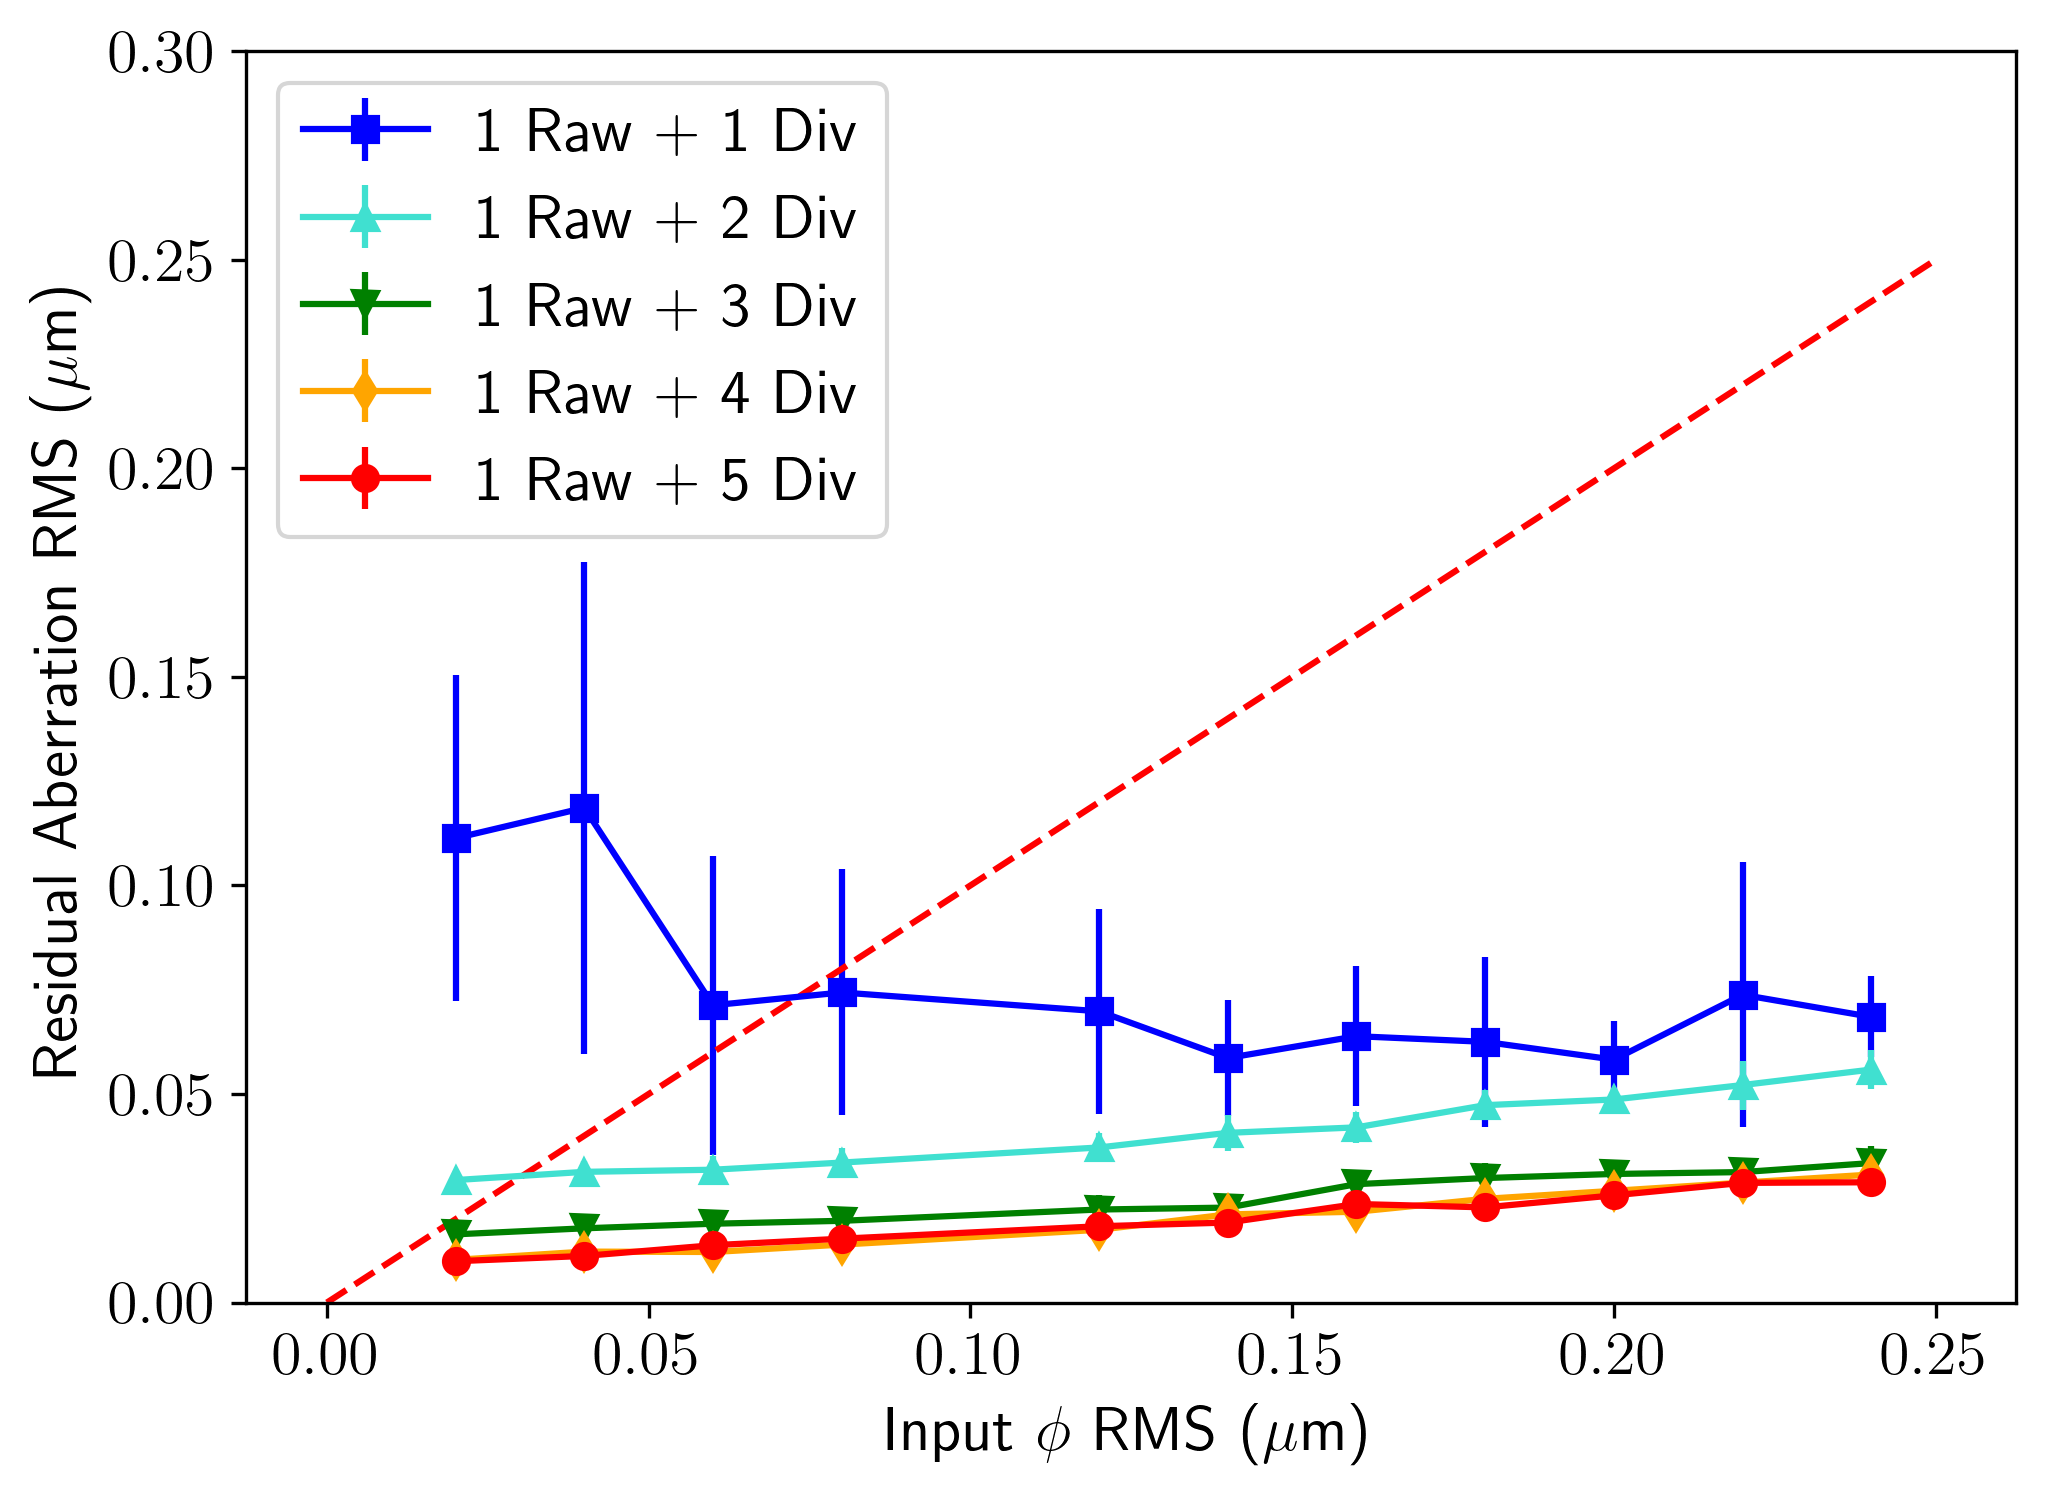

In [43]:
mode_num_names = [f"1 Raw + {int(i)} Div" for i in range(1, 6)]

c_true = np.load("results/bias_num_1p_true.npy")
c_converged = np.load("results/bias_num_1p_converged.npy")
modes = get_johnson_modes()

fig, ax = plt.subplots(dpi=300)

colors = ["blue", "turquoise", "green", "orange", "red"]
markers = ["s", "^", "v", "d", "o"]
for j, mode_num_name in enumerate(mode_num_names):
    rms_list = np.zeros((len(rms_vals), num_samples))

    for k, img_rms in enumerate(rms_vals_microns):
        rms = np.zeros(num_samples)

        for i in range(num_samples):
            this_c_true = c_true[i, j, k]
            this_c_converged = c_converged[i, j, k]

            a_true = Aberration(modes, this_c_true)
            a_converged = Aberration(modes, this_c_converged)

            rms[i] = zernike_RMS_difference(a_true, a_converged, alpha) 

        rms_list[k] = rms * (532/1000)
        #* 523 nm / wv * 1 mum /1000 nm

    ax.errorbar(
        rms_vals_microns,
        np.mean(rms_list, axis=1),
        np.std(rms_list, axis=1),
        label=f"{mode_num_name}",
        marker = markers[j],
        c = colors[j]
    )

ax.legend()
#ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel("Input $\phi$ RMS ($\mu$m)")
ax.set_ylabel("Residual Aberration RMS ($\mu$m)")
ax.set_ylim(0, 0.3)
x = np.arange(0, 0.26, 0.01)
ax.plot(x, x, ls = "dashed", color = "red")